## *Problem Overview*

This project focuses on developing a machine learning based
telecommunications customer intelligence system.

The project uses customer demographic, tenure, service, billing,
satisfaction and behavioral information to develop predictive models.

The Regression track focuses on estimating Customer Lifetime Value (CLTV).
The Classification track focuses on customer churn prediction.

## *Problem Statement*

Telecommunications companies need to understand the value of their
customers in order to support effective customer management and
retention strategies.

The objective of the Regression track is to develop machine learning
models that estimate the Customer Lifetime Value (CLTV) of a customer
using demographic, tenure, service, billing and satisfaction-related
features.

### *Regression Objective*

The regression task treats CLTV as the continuous target variable.

The project compares multiple regression algorithms and evaluates them
using R², RMSE and MAE on a common held-out test set.

## *Import Required Libraries*

### *Import Python Libraries*

In [83]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    PolynomialFeatures
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

### *Library Purpose*

Pandas and NumPy are used for data manipulation and numerical operations.

Matplotlib and Seaborn are used for exploratory data visualisation.

Scikit-learn is used for preprocessing, model training, hyperparameter
tuning and evaluation.

A random state of 42 is used wherever applicable to ensure reproducibility.

## *Dataset Loading*

### *Load Raw Dataset*

In [84]:
!git clone https://github.com/manaswiniyoshitha2006-netizen/ML-Evaluation.git
%cd ML-Evaluation

Cloning into 'ML-Evaluation'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 41 (delta 11), reused 6 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 2.74 MiB | 9.33 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/ML-Evaluation/ML-Evaluation


In [85]:
!ls data

master_clean.csv	regression_test.csv   TelcoCustomerChurn.csv
regression_dataset.csv	regression_train.csv


In [86]:
df_raw = pd.read_csv("data/TelcoCustomerChurn.csv")

df = df_raw.copy()

print("Dataset loaded successfully.")

Dataset loaded successfully.


### *Dataset Dimensions*

In [87]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 50


### *First Five Records*

In [88]:
df.head()

,CustomerID,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,Country,State,...,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,CustomerStatus,ChurnLabel,ChurnScore,CLTV,ChurnCategory,ChurnReason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


### *Last Five Records*

In [89]:
df.tail()

,CustomerID,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,Country,State,...,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,CustomerStatus,ChurnLabel,ChurnScore,CLTV,ChurnCategory,ChurnReason
7038,2569-WGERO,Female,30,No,No,No,No,0,United States,California,...,0,1639.44,3039.53,5,Stayed,No,45,5306,NaN,NaN
7039,6840-RESVB,Male,38,No,No,Yes,Yes,2,United States,California,...,0,865.20,2807.47,3,Stayed,No,59,2140,NaN,NaN
7040,2234-XADUH,Female,30,No,No,Yes,Yes,2,United States,California,...,0,2135.52,9453.04,4,Stayed,No,71,5560,NaN,NaN
7041,4801-JZAZL,Female,32,No,No,Yes,Yes,2,United States,California,...,0,0.00,319.21,4,Stayed,No,59,2793,NaN,NaN
7042,3186-AJIEK,Male,44,No,No,No,No,0,United States,California,...,0,2043.36,8887.86,4,Stayed,No,38,5097,NaN,NaN


### *Column Names*

In [90]:
df.columns.tolist()

['CustomerID',
 'Gender',
 'Age',
 'Under30',
 'SeniorCitizen',
 'Married',
 'Dependents',
 'NumberofDependents',
 'Country',
 'State',
 'City',
 'ZipCode',
 'Latitude',
 'Longitude',
 'Population',
 'Quarter',
 'ReferredaFriend',
 'Number_of_Referrals',
 'TenureinMonths',
 'Offer',
 'PhoneService',
 'AvgMonthlyLongDistanceCharges',
 'MultipleLines',
 'InternetService',
 'InternetType',
 'AvgMonthlyGBDownload',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtectionPlan',
 'PremiumTechSupport',
 'StreamingTV',
 'StreamingMovies',
 'StreamingMusic',
 'UnlimitedData',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharge',
 'TotalCharges',
 'TotalRefunds',
 'TotalExtraDataCharges',
 'TotalLongDistanceCharges',
 'TotalRevenue',
 'SatisfactionScore',
 'CustomerStatus',
 'ChurnLabel',
 'ChurnScore',
 'CLTV',
 'ChurnCategory',
 'ChurnReason']

## *Dataset Audit*

### *Dataset Information*

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     7043 non-null   object 
 1   Gender                         7043 non-null   object 
 2   Age                            7043 non-null   int64  
 3   Under30                        7043 non-null   object 
 4   SeniorCitizen                  7043 non-null   object 
 5   Married                        7043 non-null   object 
 6   Dependents                     7043 non-null   object 
 7   NumberofDependents             7043 non-null   int64  
 8   Country                        7043 non-null   object 
 9   State                          7043 non-null   object 
 10  City                           7043 non-null   object 
 11  ZipCode                        7043 non-null   int64  
 12  Latitude                       7043 non-null   f

### *Data Types*

In [92]:
df.dtypes

,0
CustomerID,object
Gender,object
Age,int64
Under30,object
SeniorCitizen,object
Married,object
Dependents,object
NumberofDependents,int64
Country,object
State,object


### *Numerical Descriptive Statistics*

In [93]:
df.describe()

,Age,NumberofDependents,ZipCode,Latitude,Longitude,Population,Number_of_Referrals,TenureinMonths,AvgMonthlyLongDistanceCharges,AvgMonthlyGBDownload,MonthlyCharge,TotalCharges,TotalRefunds,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,ChurnScore,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


### *Categorical Descriptive Statistics*

In [94]:
df.describe(include="object")

,CustomerID,Gender,Under30,SeniorCitizen,Married,Dependents,Country,State,City,Quarter,...,StreamingMovies,StreamingMusic,UnlimitedData,Contract,PaperlessBilling,PaymentMethod,CustomerStatus,ChurnLabel,ChurnCategory,ChurnReason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,1869,1869
unique,7043,2,2,2,2,2,1,1,1106,1,...,2,2,2,3,2,3,3,2,5,20
top,3186-AJIEK,Male,No,No,No,No,United States,California,Los Angeles,Q3,...,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Stayed,No,Competitor,Competitor had better devices
freq,1,3555,5642,5901,3641,5416,7043,7043,293,7043,...,4311,4555,4745,3610,4171,3909,4720,5174,841,313


### *Numerical and Categorical Feature Identification*

In [95]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical features:")
print(numeric_columns)

print("\nCategorical features:")
print(categorical_columns)

Numerical features:
['Age', 'NumberofDependents', 'ZipCode', 'Latitude', 'Longitude', 'Population', 'Number_of_Referrals', 'TenureinMonths', 'AvgMonthlyLongDistanceCharges', 'AvgMonthlyGBDownload', 'MonthlyCharge', 'TotalCharges', 'TotalRefunds', 'TotalExtraDataCharges', 'TotalLongDistanceCharges', 'TotalRevenue', 'SatisfactionScore', 'ChurnScore', 'CLTV']

Categorical features:
['CustomerID', 'Gender', 'Under30', 'SeniorCitizen', 'Married', 'Dependents', 'Country', 'State', 'City', 'Quarter', 'ReferredaFriend', 'Offer', 'PhoneService', 'MultipleLines', 'InternetService', 'InternetType', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtectionPlan', 'PremiumTechSupport', 'StreamingTV', 'StreamingMovies', 'StreamingMusic', 'UnlimitedData', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'CustomerStatus', 'ChurnLabel', 'ChurnCategory', 'ChurnReason']


## *Missing Value Analysis*

### *Missing Value Count*

In [96]:
missing_count = df.isnull().sum()

missing_count.sort_values(
    ascending=False
)

,0
ChurnReason,5174
ChurnCategory,5174
Offer,3877
InternetType,1526
SeniorCitizen,0
Married,0
Age,0
Under30,0
Country,0
State,0


### *Missing Value Percentage*

In [97]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage":
        (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
ChurnReason,5174,73.463013
ChurnCategory,5174,73.463013
Offer,3877,55.047565
InternetType,1526,21.666903
SeniorCitizen,0,0.000000
Married,0,0.000000
Age,0,0.000000
Under30,0,0.000000
Country,0,0.000000
State,0,0.000000


### *Missing Value Interpretation*

Missing values are examined individually because a missing value may
represent a meaningful category rather than an unknown observation.

The main variables requiring attention are Offer, InternetType,
ChurnCategory and ChurnReason.

### *Analyse Missing Offer Values*

In [98]:
df["Offer"].value_counts(
    dropna=False
)

,count
Offer,
NaN,3877
Offer B,824
Offer E,805
Offer D,602
Offer A,520
Offer C,415


### *Analyse Missing Internet Type Values*

In [99]:
pd.crosstab(
    df["InternetService"],
    df["InternetType"],
    dropna=False
)

InternetType,Cable,DSL,Fiber Optic,NaN
InternetService,,,,
No,0,0,0,1526
Yes,830,1652,3035,0


### *Analyse Missing Churn Category Values*

In [100]:
pd.crosstab(
    df["ChurnLabel"],
    df["ChurnCategory"],
    dropna=False
)

ChurnCategory,Attitude,Competitor,Dissatisfaction,Other,Price,NaN
ChurnLabel,,,,,,
No,0,0,0,0,0,5174
Yes,314,841,303,200,211,0


### *Missing Value Treatment Strategy*

Offer:
Missing values are interpreted as customers for whom no offer is recorded.
They are replaced with the explicit category "No Offer".

InternetType:
Missing values correspond to customers without an internet service.
They are replaced with "No Internet".

ChurnCategory and ChurnReason:
These variables describe churn outcomes and are not required as predictive
features for the regression model. Their missing values are therefore not
statistically imputed.

### *Apply Semantic Missing Value Treatment*

In [101]:
df["Offer"] = df["Offer"].fillna("No Offer")

df["InternetType"] = df["InternetType"].fillna(
    "No Internet"
)

### *Verify Missing Values After Treatment*

In [102]:
df.isnull().sum().sort_values(
    ascending=False
)

,0
ChurnReason,5174
ChurnCategory,5174
Age,0
Under30,0
SeniorCitizen,0
Married,0
Dependents,0
NumberofDependents,0
Country,0
State,0


## *Duplicate Analysis*

### *Duplicate Row Check*

In [103]:
duplicate_rows = df.duplicated().sum()

print(
    "Number of duplicate rows:",
    duplicate_rows
)

Number of duplicate rows: 0


### *Duplicate Customer ID Check*

In [104]:
duplicate_customer_ids = (
    df["CustomerID"].duplicated().sum()
)

print(
    "Number of duplicate CustomerIDs:",
    duplicate_customer_ids
)

Number of duplicate CustomerIDs: 0


### *Duplicate Treatment Decision*

No duplicate rows or duplicate CustomerIDs were identified in the
dataset. Therefore, no observations are removed due to duplication.

## *Data Consistency and Logical Validation*

### *Under30 and Age Consistency*

In [105]:
under30_inconsistency = (
    (df["Under30"] == "Yes") !=
    (df["Age"] < 30)
).sum()

print(
    "Under30 inconsistencies:",
    under30_inconsistency
)

Under30 inconsistencies: 0


### *SeniorCitizen and Age Consistency*

In [106]:
senior_inconsistency = (
    (df["SeniorCitizen"] == "Yes") !=
    (df["Age"] >= 65)
).sum()

print(
    "SeniorCitizen inconsistencies:",
    senior_inconsistency
)

SeniorCitizen inconsistencies: 0


### *Dependents Consistency*

In [107]:
dependent_inconsistency = (
    (df["Dependents"] == "Yes") !=
    (df["NumberofDependents"] > 0)
).sum()

print(
    "Dependents inconsistencies:",
    dependent_inconsistency
)

Dependents inconsistencies: 0


### *Referral Consistency*

In [108]:
referral_inconsistency = (
    (df["ReferredaFriend"] == "Yes") !=
    (df["Number_of_Referrals"] > 0)
).sum()

print(
    "Referral inconsistencies:",
    referral_inconsistency
)

Referral inconsistencies: 0


## *Data Leakage and Redundancy Analysis*

### *Regression Target*

The regression target is CLTV.

In [109]:
target = "CLTV"

print("Regression target:", target)

Regression target: CLTV


### *TotalRevenue Redundancy Check*

In [110]:
calculated_revenue = (
    df["TotalCharges"]
    + df["TotalLongDistanceCharges"]
    + df["TotalExtraDataCharges"]
    - df["TotalRefunds"]
)

revenue_difference = (
    df["TotalRevenue"] -
    calculated_revenue
)

print(
    "Maximum absolute difference:",
    revenue_difference.abs().max()
)

Maximum absolute difference: 1.8189894035458565e-12


### *Regression Leakage and Redundancy Decisions*

The following variables will not be used as regression predictors:

CustomerID:
Used only as an identifier.

Country, State, City, ZipCode, Latitude and Longitude:
These are location-related fields and are not required for the selected
customer-value modelling objective.

Quarter:
Represents reporting-period information rather than a direct customer
characteristic.

Under30:
Redundant with Age.

Dependents:
Redundant with NumberofDependents.

ReferredaFriend:
Redundant with Number_of_Referrals.

TotalRevenue:
Derived from existing billing variables.

CustomerStatus:
Contains customer status information closely related to churn.

ChurnLabel:
Reserved as the target for the classification track.

ChurnScore:
An existing churn-related predictive score and therefore not used as an
input to the regression model.

ChurnCategory and ChurnReason:
Contain churn outcome information and are not used as regression predictors.

CLTV Category:
Derived from CLTV and therefore would leak target information into the model.

## *Master Clean Dataset*

### *Create Master Clean Dataset*

In [111]:
master_clean = df.copy()

print(
    "Master clean dataset shape:",
    master_clean.shape
)

Master clean dataset shape: (7043, 50)


In [112]:
master_clean.to_csv("data/master_clean.csv", index=False)

print("Master clean dataset saved successfully.")

Master clean dataset saved successfully.


### *Verify Master Dataset*

In [113]:
print("Shape:", master_clean.shape)

print(
    "\nRemaining missing values:"
)

print(
    master_clean.isnull().sum()
    .sort_values(ascending=False)
    .head(10)
)

Shape: (7043, 50)

Remaining missing values:
ChurnReason           5174
ChurnCategory         5174
Age                      0
Under30                  0
SeniorCitizen            0
Married                  0
Dependents               0
NumberofDependents       0
Country                  0
State                    0
dtype: int64


### *Save Master Clean Dataset for Team*

In [114]:
master_clean.to_csv(
    "master_clean.csv",
    index=False
)

print(
    "master_clean.csv saved successfully."
)

master_clean.csv saved successfully.


## *Exploratory Data Analysis*

### *Target Variable Distribution*

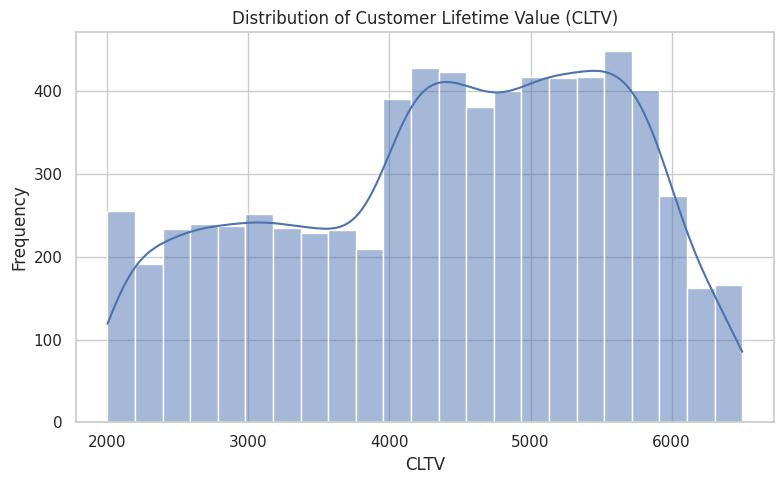

In [115]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=master_clean,
    x="CLTV",
    kde=True
)

plt.title(
    "Distribution of Customer Lifetime Value (CLTV)"
)

plt.xlabel("CLTV")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### *Observation – CLTV Distribution*

The CLTV distribution ranges from approximately 2,003 to 6,500, with a mean of about 4,400 and a median of about 4,527. The distribution is slightly left-skewed, indicating that most customers have moderate to high CLTV values, with relatively fewer customers at the lower end. There are no extreme CLTV outliers based on the IQR analysis. Therefore, CLTV is suitable for regression modelling without requiring outlier removal or transformation.

### *NUMERICAL FEATURES*

### *Numerical Feature Distributions*

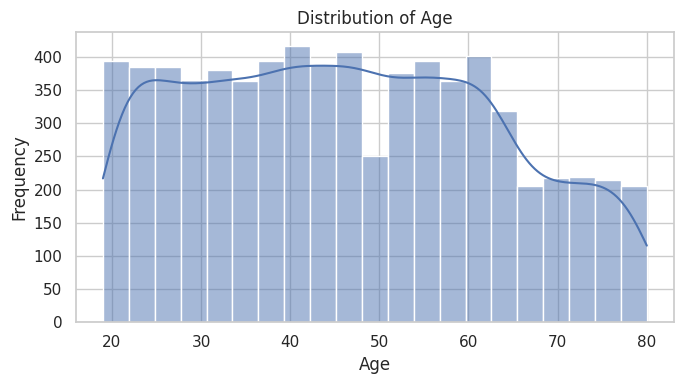

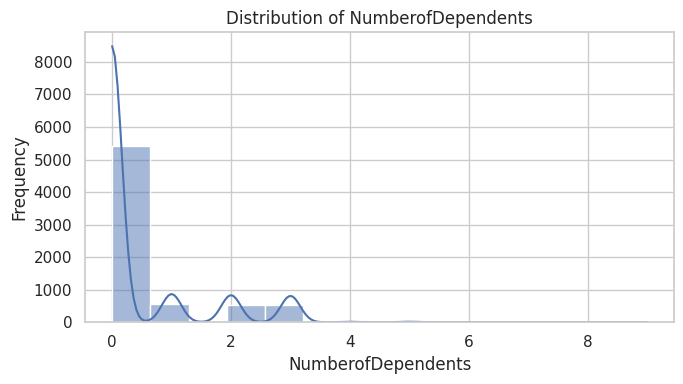

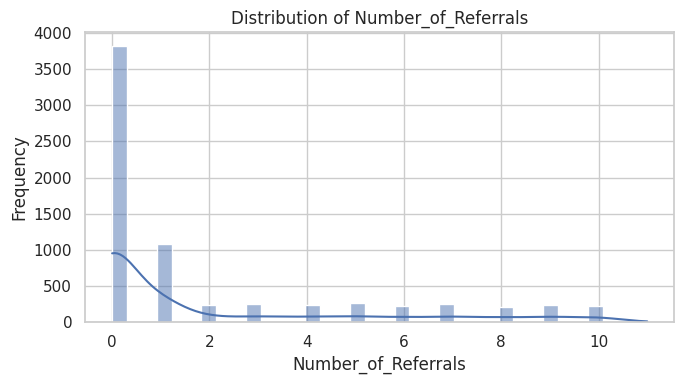

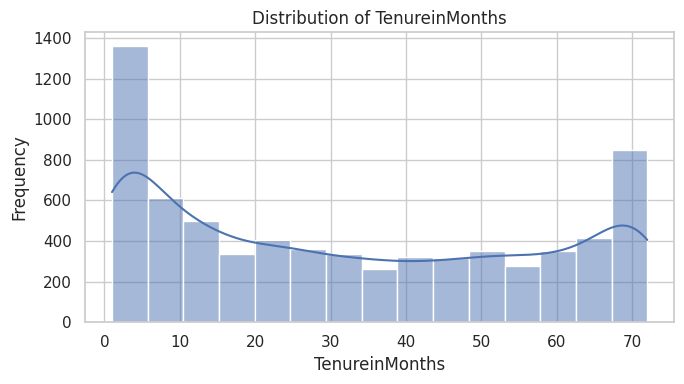

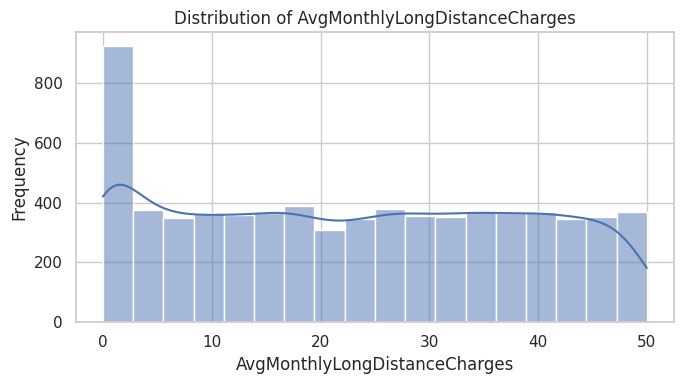

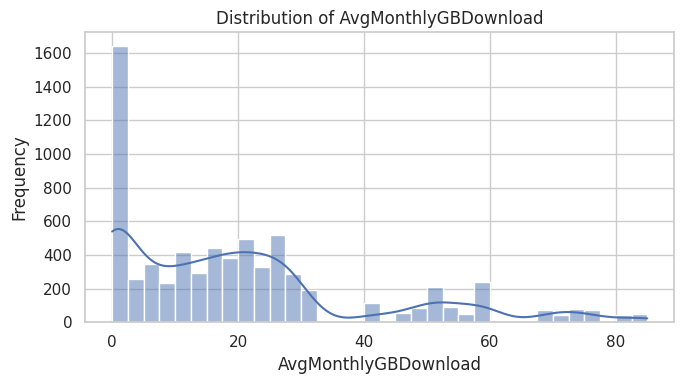

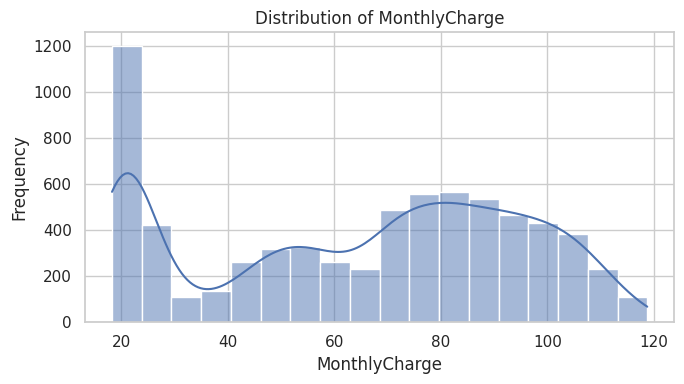

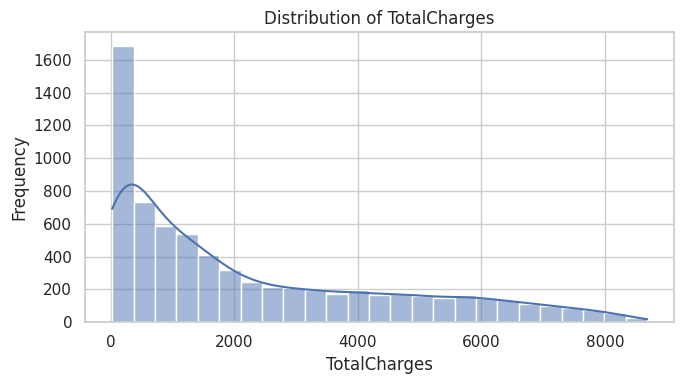

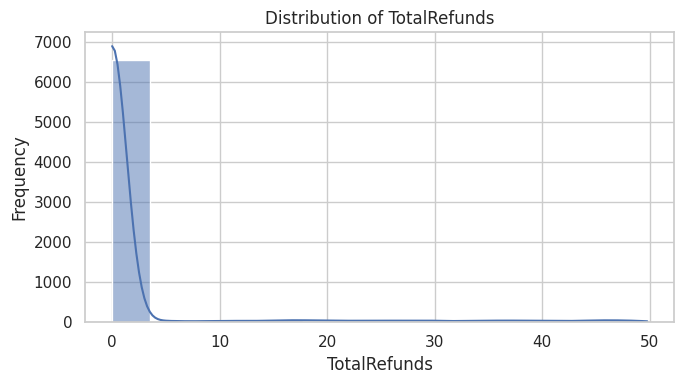

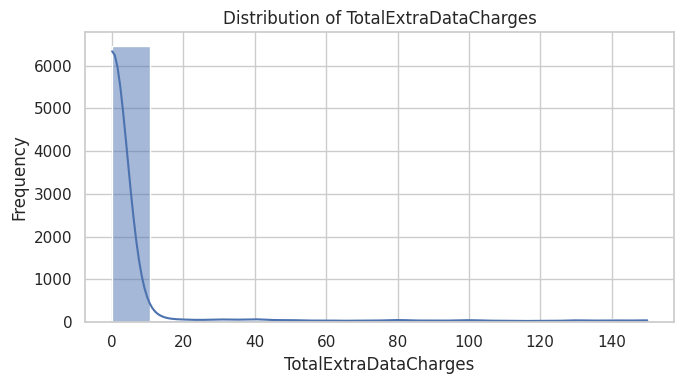

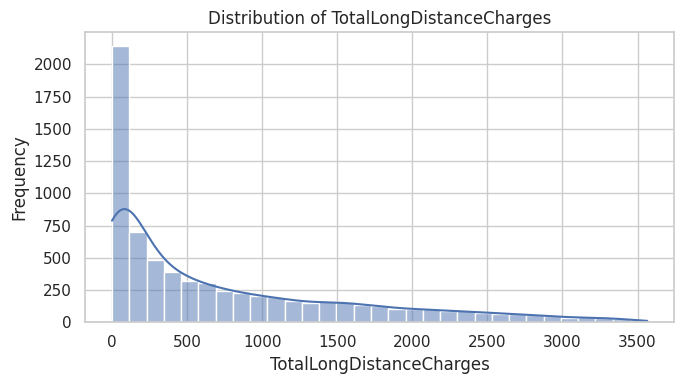

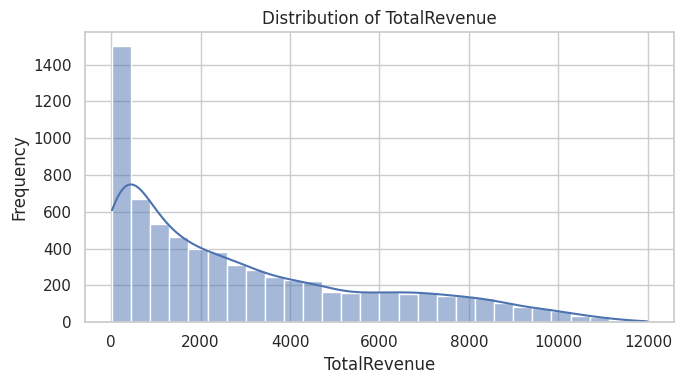

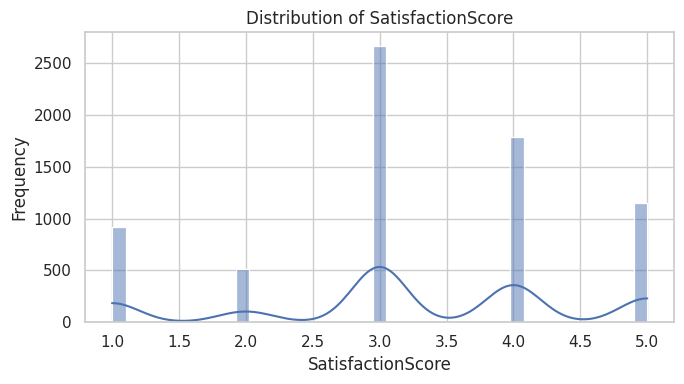

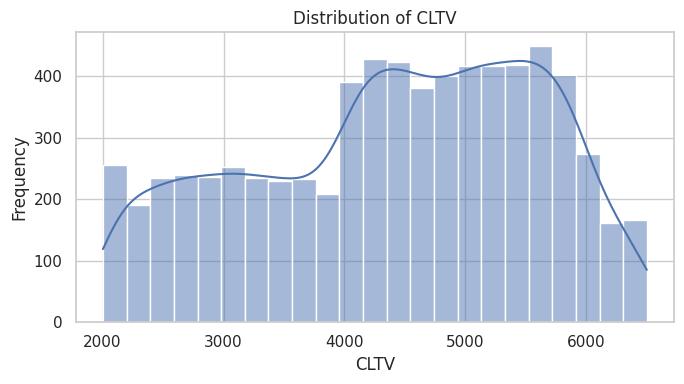

In [116]:
numeric_eda_columns = [
    "Age",
    "NumberofDependents",
    "Number_of_Referrals",
    "TenureinMonths",
    "AvgMonthlyLongDistanceCharges",
    "AvgMonthlyGBDownload",
    "MonthlyCharge",
    "TotalCharges",
    "TotalRefunds",
    "TotalExtraDataCharges",
    "TotalLongDistanceCharges",
    "TotalRevenue",
    "SatisfactionScore",
    "CLTV"
]

for col in numeric_eda_columns:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=master_clean,
        x=col,
        kde=True
    )

    plt.title(
        f"Distribution of {col}"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

### *CATEGORICAL FEATURES*

### *Categorical Feature Distributions*

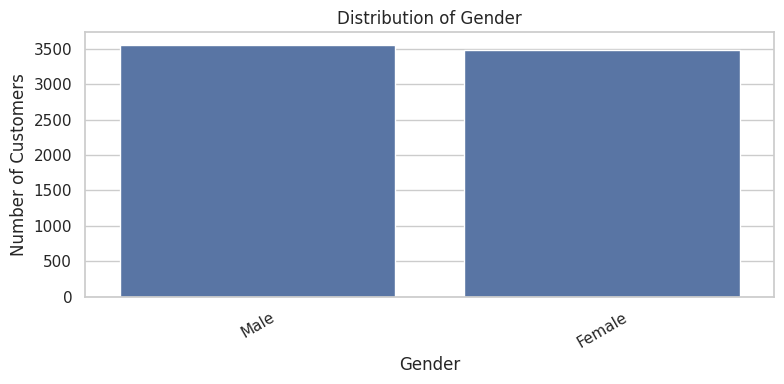

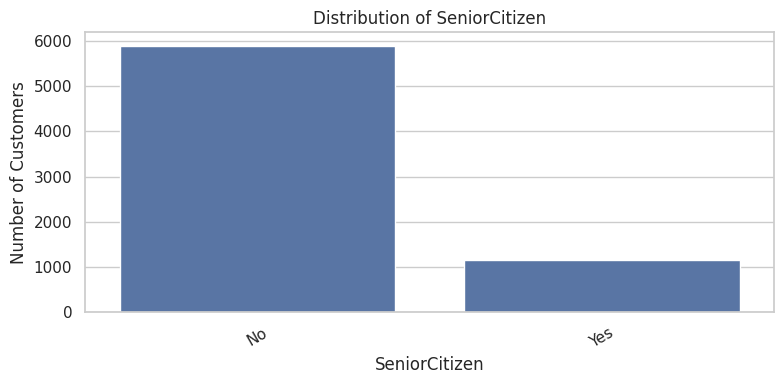

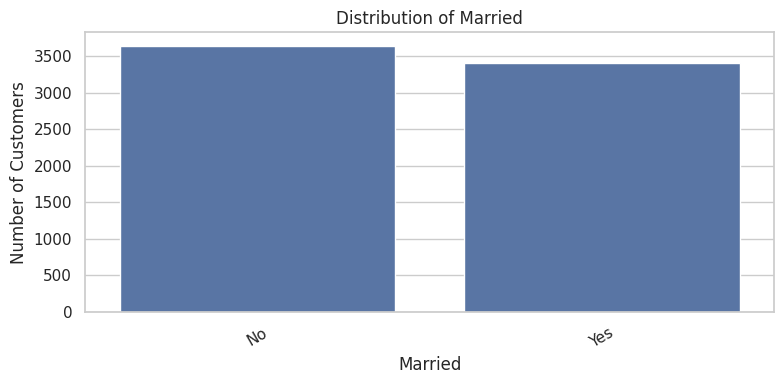

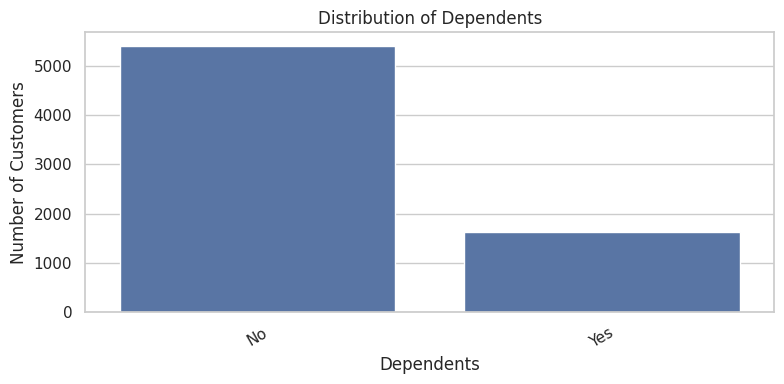

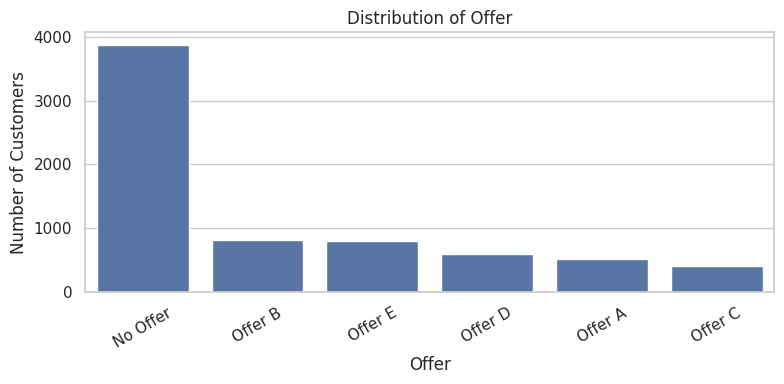

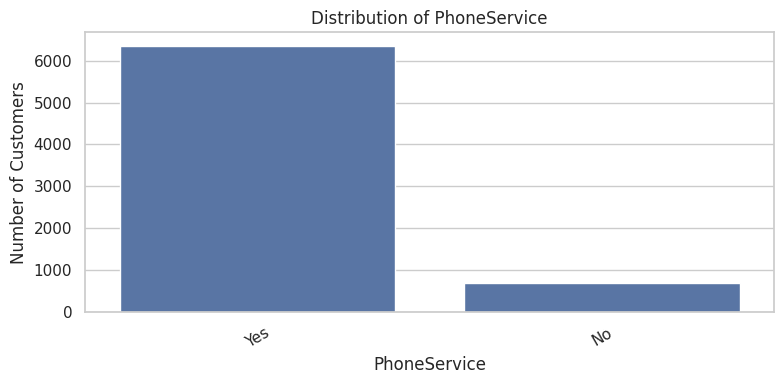

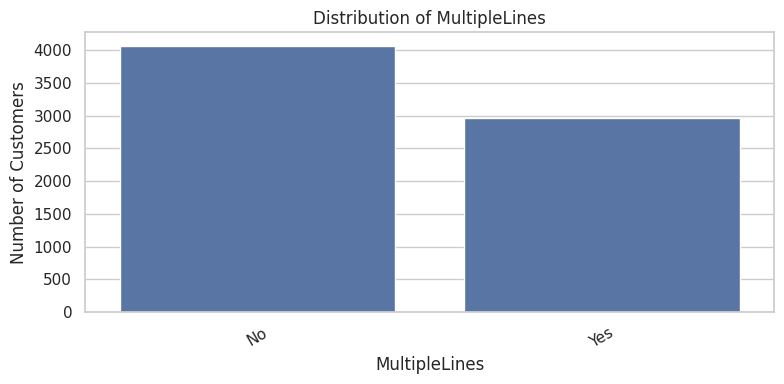

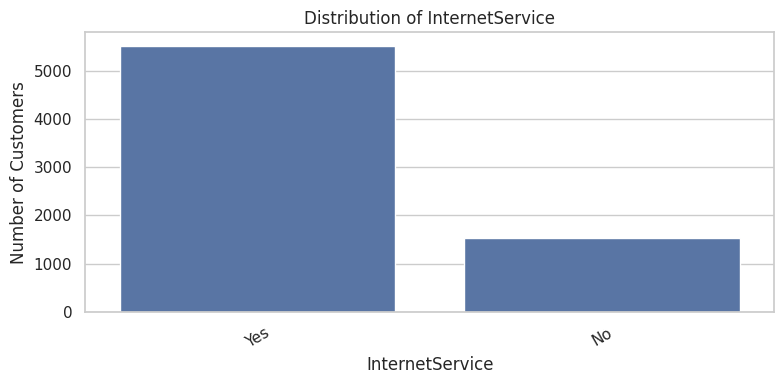

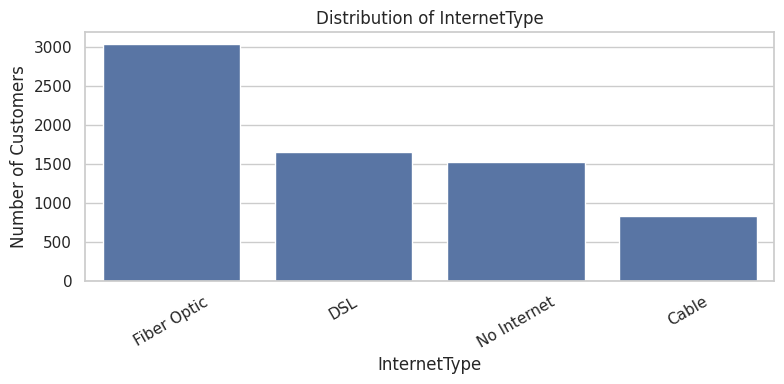

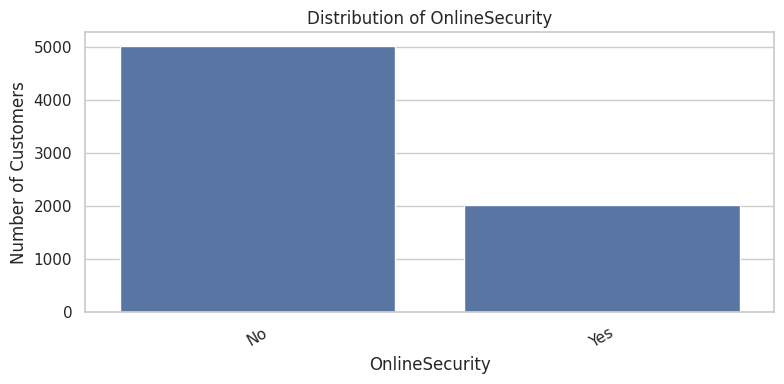

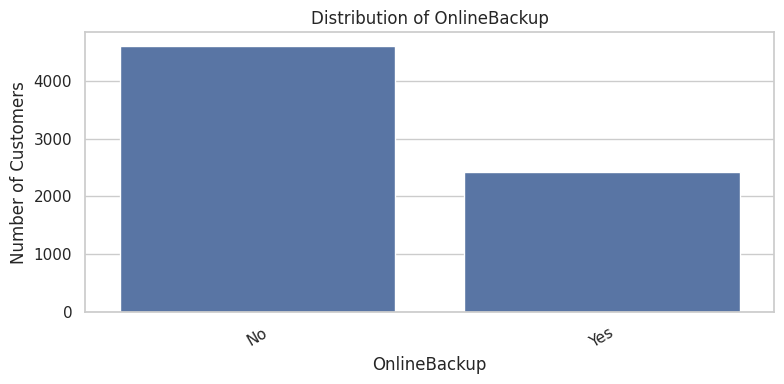

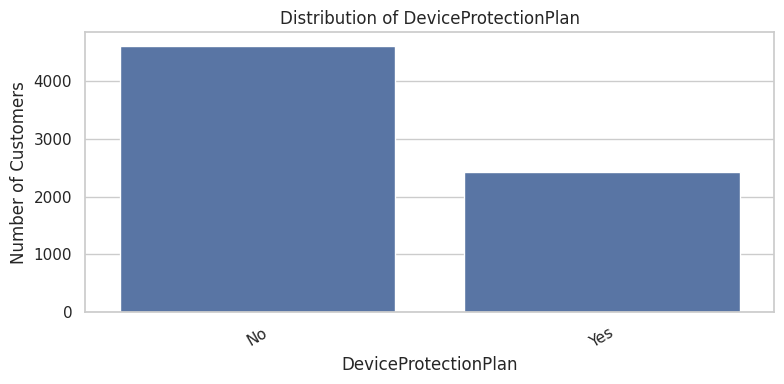

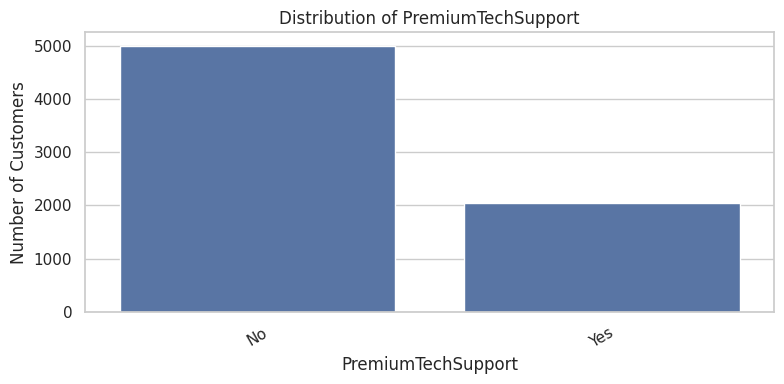

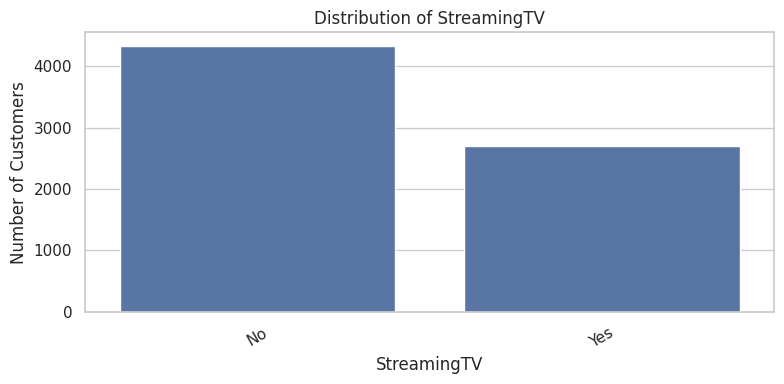

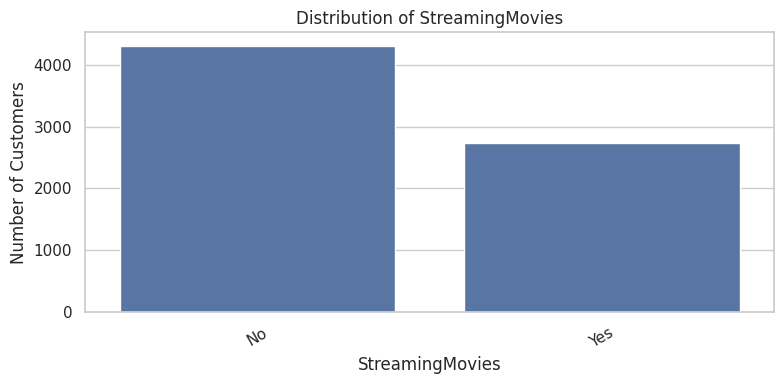

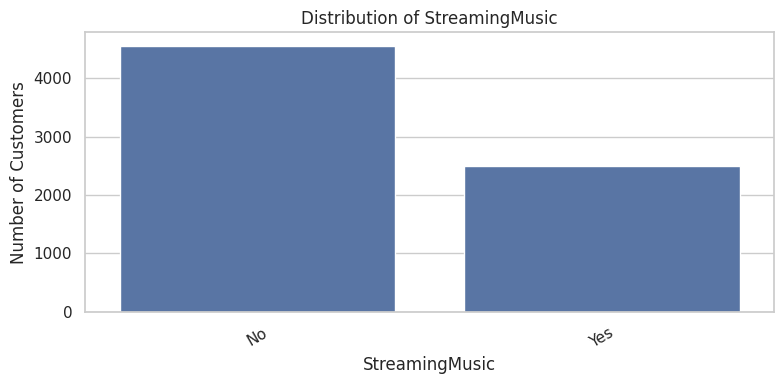

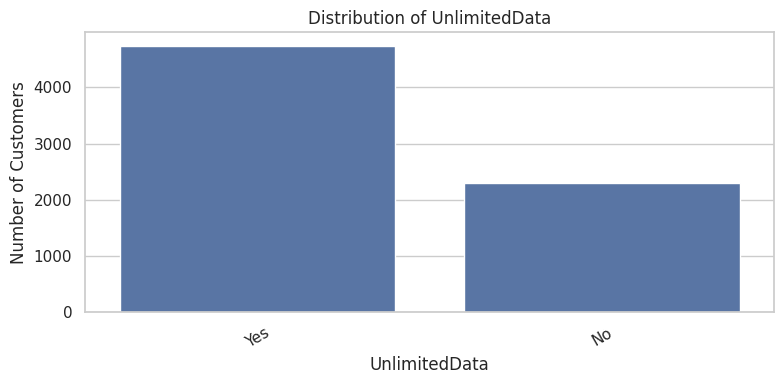

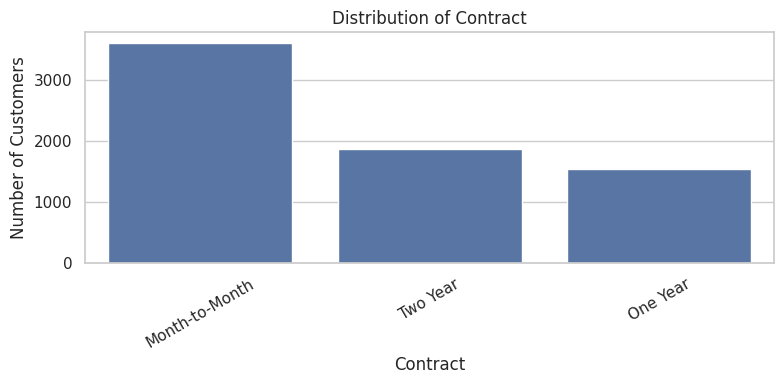

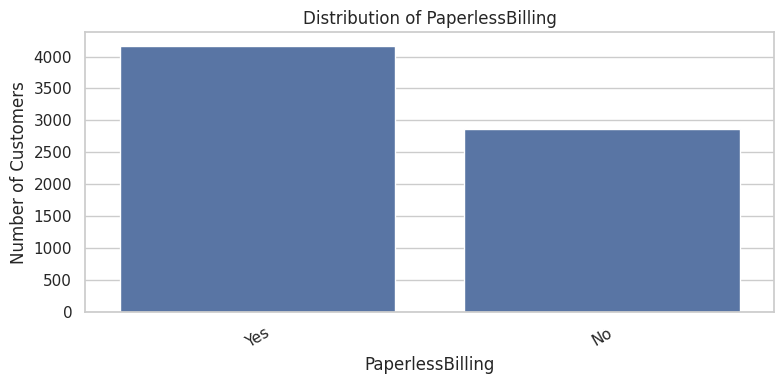

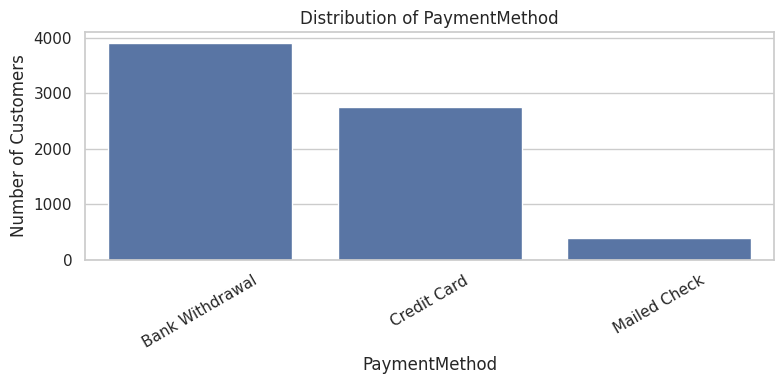

In [117]:
categorical_eda_columns = [
    "Gender",
    "SeniorCitizen",
    "Married",
    "Dependents",
    "Offer",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "InternetType",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtectionPlan",
    "PremiumTechSupport",
    "StreamingTV",
    "StreamingMovies",
    "StreamingMusic",
    "UnlimitedData",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for col in categorical_eda_columns:

    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=master_clean,
        x=col,
        order=master_clean[col].value_counts().index
    )

    plt.title(
        f"Distribution of {col}"
    )

    plt.xlabel(col)
    plt.ylabel("Number of Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

### *Categorical Feature Interpretation*

The categorical feature distributions show that the dataset contains a relatively balanced distribution of Gender, while most customers are not senior citizens, do not have dependents, and are married or unmarried in relatively similar proportions. Phone service is present for the majority of customers, and most customers use Internet services. Fiber Optic is the most common Internet Type among customers with Internet service. Most customers do not subscribe to additional services such as Online Security, Online Backup, Device Protection and Premium Tech Support. Month-to-Month is the most common contract type, followed by Two Year and One Year contracts. Bank Withdrawal is the most common payment method. These distributions provide useful information about customer characteristics and service adoption patterns for regression modelling.

### *CORRELATION HEATMAP*

### *Correlation Heatmap*

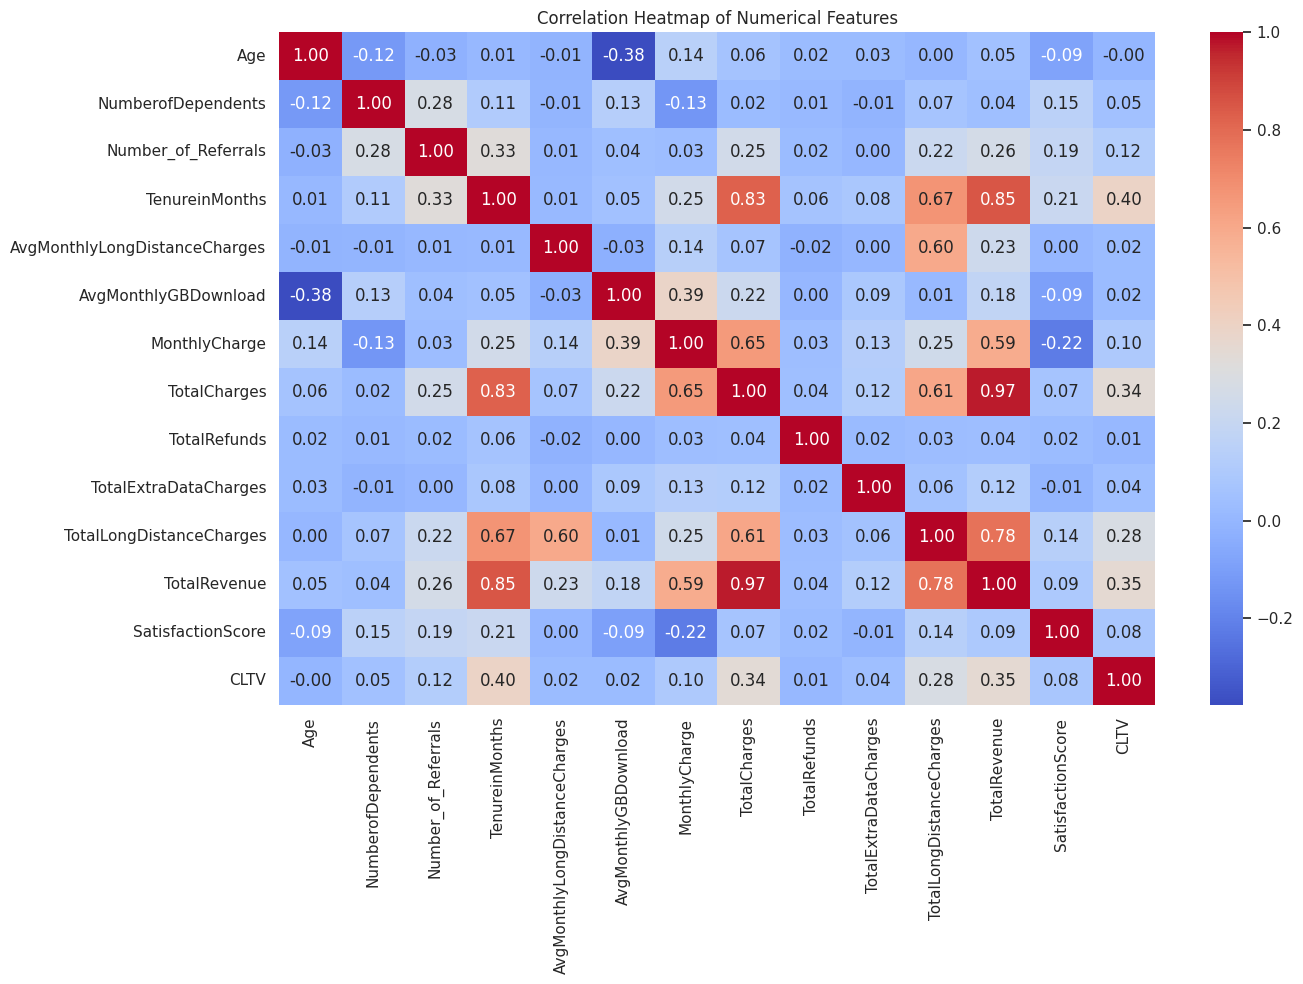

In [118]:
correlation_columns = [
    "Age",
    "NumberofDependents",
    "Number_of_Referrals",
    "TenureinMonths",
    "AvgMonthlyLongDistanceCharges",
    "AvgMonthlyGBDownload",
    "MonthlyCharge",
    "TotalCharges",
    "TotalRefunds",
    "TotalExtraDataCharges",
    "TotalLongDistanceCharges",
    "TotalRevenue",
    "SatisfactionScore",
    "CLTV"
]

plt.figure(figsize=(14, 10))

sns.heatmap(
    master_clean[
        correlation_columns
    ].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap of Numerical Features"
)

plt.tight_layout()
plt.show()

### *Correlation Heatmap Interpretation*

The correlation heatmap indicates that TenureinMonths has the strongest positive correlation with CLTV among the numerical variables, with a correlation of approximately 0.40. TotalCharges and TotalRevenue also show moderate positive correlations with CLTV, at approximately 0.34 and 0.35 respectively. TotalLongDistanceCharges has a weaker positive relationship with CLTV. MonthlyCharge has only a weak positive correlation with CLTV, while Age has almost no linear relationship with the target. Overall, the numerical features show mostly weak-to-moderate linear relationships with CLTV, suggesting that CLTV may depend on multiple features rather than a single dominant predictor.

### *SCATTER PLOTS*

### *Feature-Target Relationship Analysis*

### Monthly Charge vs CLTV

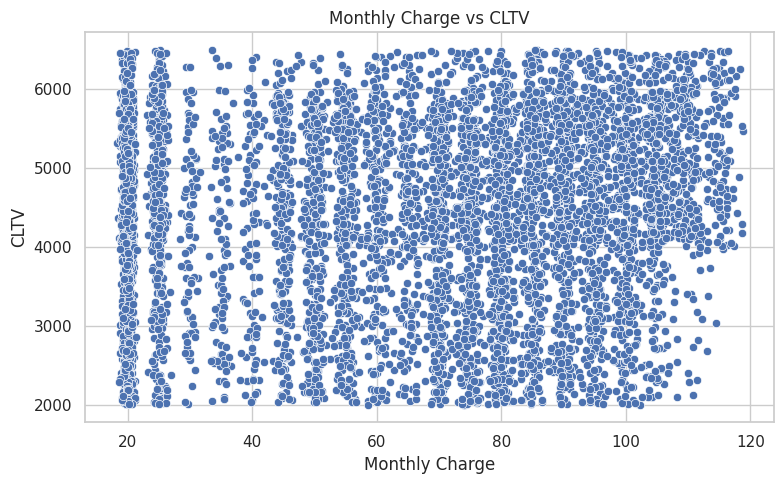

In [119]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=master_clean,
    x="MonthlyCharge",
    y="CLTV"
)

plt.title(
    "Monthly Charge vs CLTV"
)

plt.xlabel("Monthly Charge")
plt.ylabel("CLTV")

plt.tight_layout()
plt.show()

### *Monthly Charge vs CLTV*

The scatter plot shows a weak positive relationship between MonthlyCharge and CLTV. The correlation is approximately 0.10, indicating that higher monthly charges are associated with slightly higher CLTV, but the relationship is not strong. The considerable spread of CLTV values across different MonthlyCharge values suggests that MonthlyCharge alone is not a strong predictor of CLTV.

### Tenure vs CLTV

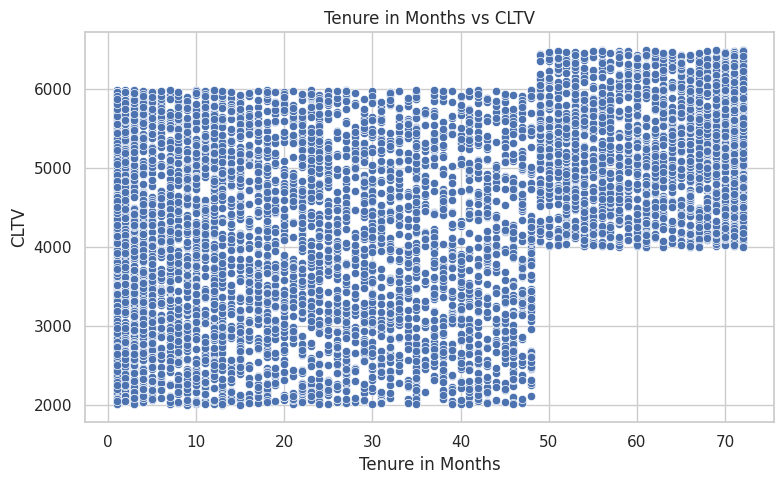

In [120]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=master_clean,
    x="TenureinMonths",
    y="CLTV"
)

plt.title(
    "Tenure in Months vs CLTV"
)

plt.xlabel("Tenure in Months")
plt.ylabel("CLTV")

plt.tight_layout()
plt.show()

### *Tenure vs CLTV*

The scatter plot shows a clearer positive relationship between TenureinMonths and CLTV compared with MonthlyCharge. The correlation is approximately 0.40, making TenureinMonths one of the stronger numerical predictors of CLTV in the dataset. Customers with longer tenure generally tend to have higher CLTV values, although considerable variation remains at different tenure levels. This indicates that customer relationship duration is an important factor in estimating CLTV.

### Total Charges vs CLTV

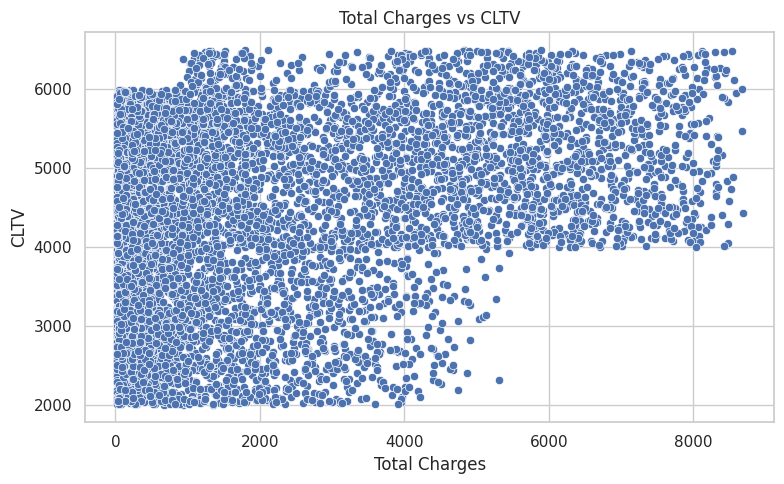

In [121]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=master_clean,
    x="TotalCharges",
    y="CLTV"
)

plt.title(
    "Total Charges vs CLTV"
)

plt.xlabel("Total Charges")
plt.ylabel("CLTV")

plt.tight_layout()
plt.show()

### *Total Charges vs CLTV*

The scatter plot shows a moderate positive relationship between TotalCharges and CLTV. The correlation is approximately 0.34, indicating that customers with higher cumulative charges generally tend to have higher CLTV. However, the relationship is not strong enough to predict CLTV accurately on its own, and substantial variation is visible across the range of TotalCharges.

## **Categorical Features**

### *CATEGORICAL VS TARGET*

### *CLTV Across Contract Types*

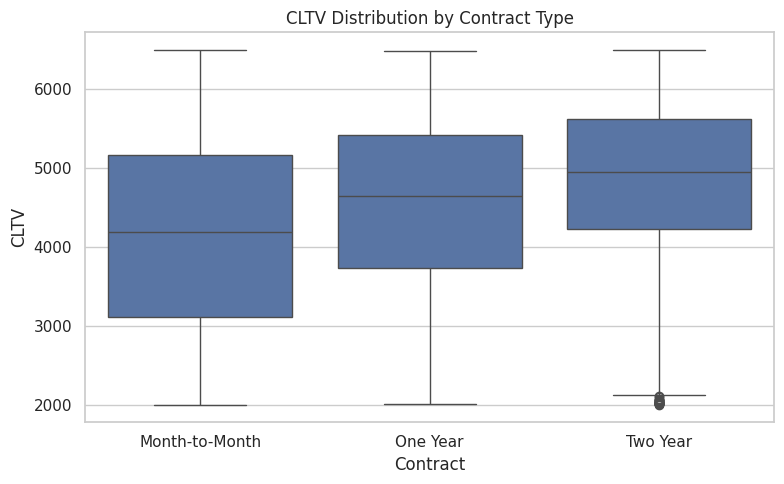

In [122]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=master_clean,
    x="Contract",
    y="CLTV"
)

plt.title(
    "CLTV Distribution by Contract Type"
)

plt.xlabel("Contract")
plt.ylabel("CLTV")

plt.tight_layout()
plt.show()

### *CLTV Across Contract Types*

The boxplot indicates differences in CLTV across contract types. Customers with Two Year contracts have the highest average CLTV at approximately 4,822, followed by One Year contracts at approximately 4,501. Month-to-Month customers have the lowest average CLTV at approximately 4,137. This suggests that customers with longer-term contracts tend to have higher customer lifetime value. Contract type therefore provides useful information for predicting CLTV.

## *Outlier Analysis*

### *Numerical Variables Selected for Outlier Analysis*

In [123]:
outlier_columns = [
    "Age",
    "NumberofDependents",
    "Number_of_Referrals",
    "TenureinMonths",
    "AvgMonthlyLongDistanceCharges",
    "AvgMonthlyGBDownload",
    "MonthlyCharge",
    "TotalCharges",
    "TotalRefunds",
    "TotalExtraDataCharges",
    "TotalLongDistanceCharges",
    "TotalRevenue",
    "SatisfactionScore",
    "CLTV"
]

### *Boxplot Analysis*

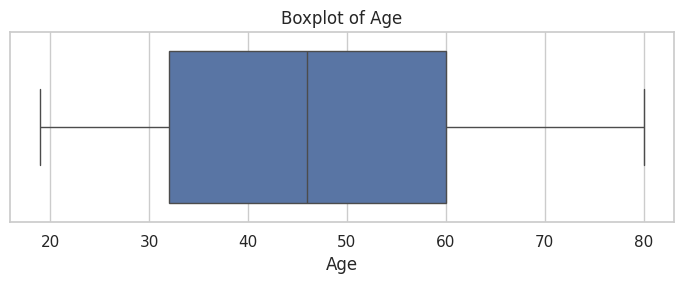

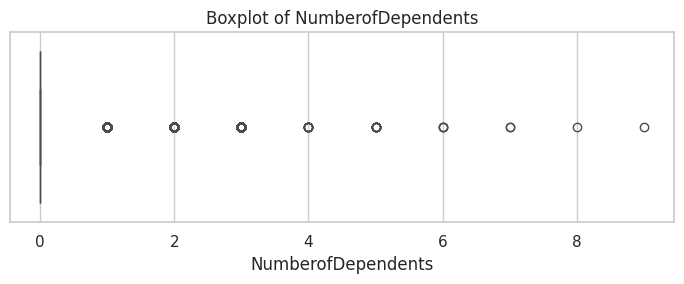

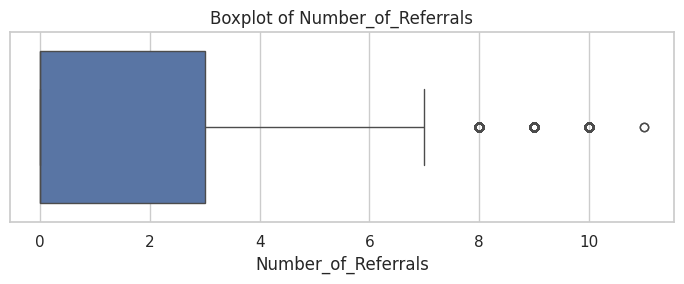

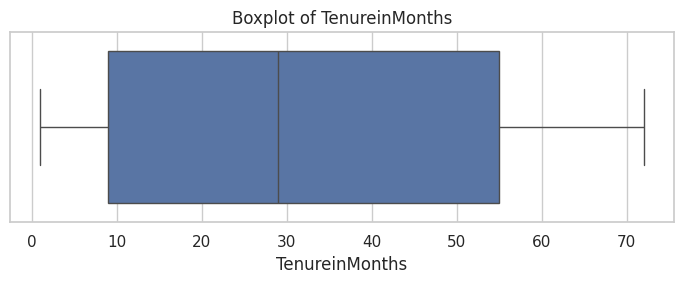

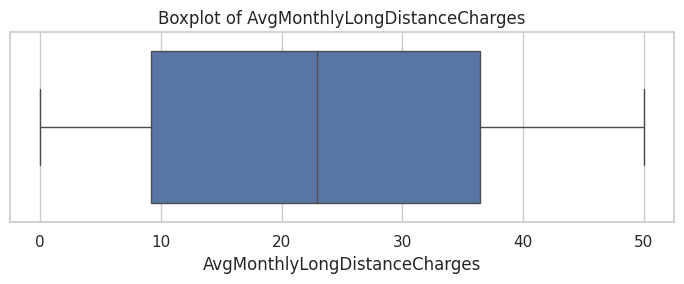

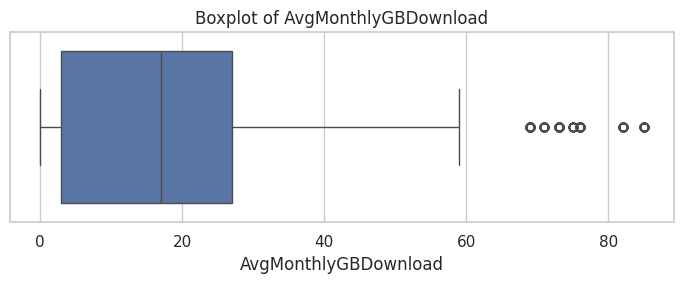

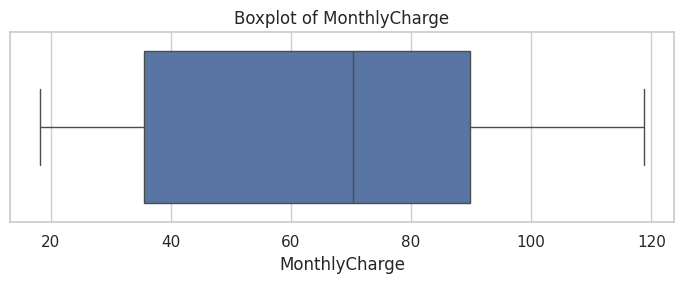

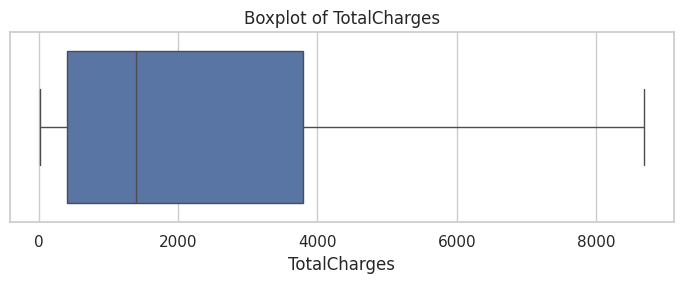

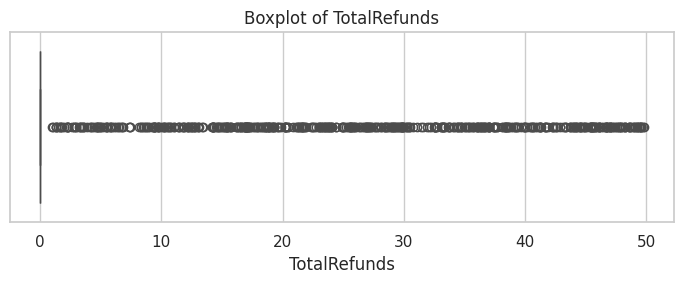

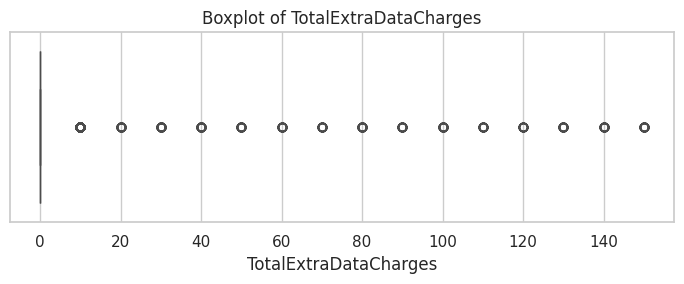

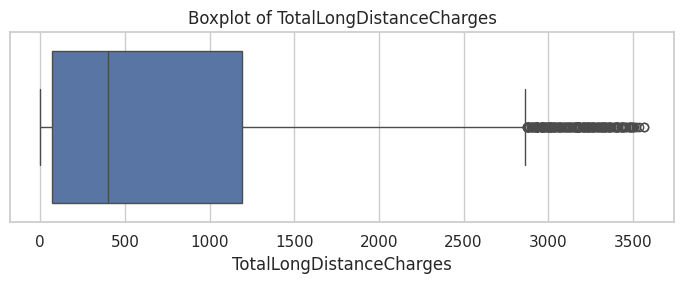

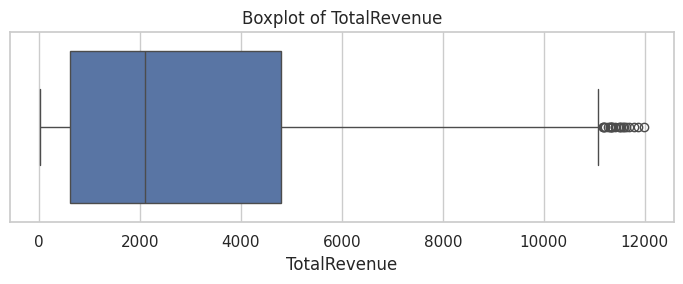

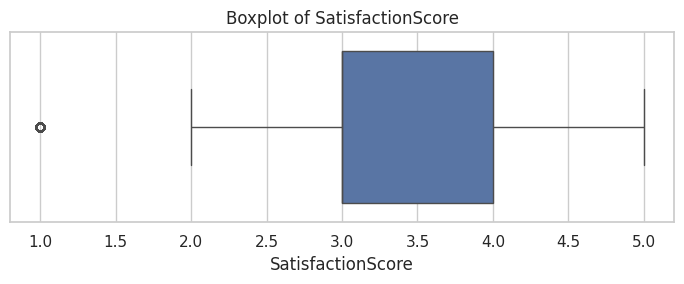

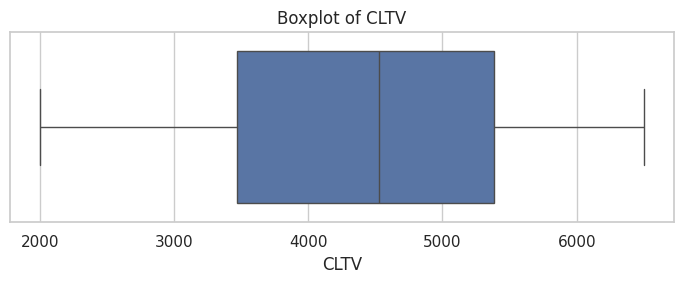

In [124]:
for col in outlier_columns:

    plt.figure(figsize=(7, 3))

    sns.boxplot(
        x=master_clean[col]
    )

    plt.title(
        f"Boxplot of {col}"
    )

    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

### *IQR-Based Outlier Detection*

In [125]:
def iqr_summary(data, columns):

    results = []

    for col in columns:

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_count = (
            (data[col] < lower_bound) |
            (data[col] > upper_bound)
        ).sum()

        outlier_percentage = (
            outlier_count /
            len(data) * 100
        )

        results.append({
            "Feature": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Outlier Count": outlier_count,
            "Outlier Percentage":
                outlier_percentage
        })

    return pd.DataFrame(results)

### *Outlier Summary*

In [126]:
outlier_summary = iqr_summary(
    master_clean,
    outlier_columns
)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Age,32.000,60.000,28.000,-10.0000,102.0000,0,0.000000
1,NumberofDependents,0.000,0.000,0.000,0.0000,0.0000,1627,23.100951
2,Number_of_Referrals,0.000,3.000,3.000,-4.5000,7.5000,676,9.598183
3,TenureinMonths,9.000,55.000,46.000,-60.0000,124.0000,0,0.000000
4,AvgMonthlyLongDistanceCharges,9.210,36.395,27.185,-31.5675,77.1725,0,0.000000
5,AvgMonthlyGBDownload,3.000,27.000,24.000,-33.0000,63.0000,362,5.139855
6,MonthlyCharge,35.500,89.850,54.350,-46.0250,171.3750,0,0.000000
7,TotalCharges,400.150,3786.600,3386.450,-4679.5250,8866.2750,0,0.000000
8,TotalRefunds,0.000,0.000,0.000,0.0000,0.0000,525,7.454210
9,TotalExtraDataCharges,0.000,0.000,0.000,0.0000,0.0000,728,10.336504


### *Outlier Treatment Decision*

Outliers are not automatically removed because extreme customer values
may represent legitimate customer behaviour, particularly for monetary
and usage-related variables.

The IQR method is used to identify potential outliers. Values are retained
when they represent plausible customer observations. Only observations
identified as genuine data-quality errors would be removed or corrected.

## *Regression Feature Selection*

### *Regression Target*

In [127]:
target = "CLTV"

print(
    "Regression target:",
    target
)

Regression target: CLTV


### *Selected Regression Features*

In [128]:
regression_features = [

    # Demographic features
    "Gender",
    "Age",
    "SeniorCitizen",
    "Married",
    "NumberofDependents",

    # Customer relationship
    "Number_of_Referrals",
    "TenureinMonths",

    # Service and usage
    "Offer",
    "PhoneService",
    "AvgMonthlyLongDistanceCharges",
    "MultipleLines",
    "InternetService",
    "InternetType",
    "AvgMonthlyGBDownload",

    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtectionPlan",
    "PremiumTechSupport",
    "StreamingTV",
    "StreamingMovies",
    "StreamingMusic",
    "UnlimitedData",

    # Account
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",

    # Billing
    "MonthlyCharge",
    "TotalCharges",
    "TotalRefunds",
    "TotalExtraDataCharges",
    "TotalLongDistanceCharges",

    # Customer experience
    "SatisfactionScore"
]

print(
    "Number of initial regression features:",
    len(regression_features)
)

Number of initial regression features: 31


### *Features Excluded from Regression*

In [129]:
excluded_regression_features = [

    "CustomerID",
    "Country",
    "State",
    "City",
    "ZipCode",
    "Latitude",
    "Longitude",
    "Quarter",

    "Under30",
    "Dependents",
    "ReferredaFriend",

    "CustomerStatus",
    "ChurnLabel",
    "ChurnScore",
    "ChurnCategory",
    "ChurnReason",

    "CLTV Category",

    "TotalRevenue"
]

print(
    "Excluded features:"
)

for feature in excluded_regression_features:
    print("-", feature)

Excluded features:
- CustomerID
- Country
- State
- City
- ZipCode
- Latitude
- Longitude
- Quarter
- Under30
- Dependents
- ReferredaFriend
- CustomerStatus
- ChurnLabel
- ChurnScore
- ChurnCategory
- ChurnReason
- CLTV Category
- TotalRevenue


### *Feature Selection Justification*

The selected variables represent customer demographics, customer
relationship characteristics, service adoption, account information,
billing behaviour and satisfaction.

Identifier and geographic fields are excluded because they do not
directly represent the intended customer-value characteristics.

Redundant variables such as Under30, Dependents and ReferredaFriend are
excluded because their information is already represented by numerical
variables.

Churn-related outcome variables are excluded to prevent information
leakage.

CLTV-derived variables are excluded because they are derived from the
regression target.

TotalRevenue is excluded because it is a derived aggregate of existing
billing variables.

## *Feature Engineering*

### *Create ServiceCount*

In [130]:
master_clean = df.copy()

print("Master clean dataset shape:", master_clean.shape)

Master clean dataset shape: (7043, 50)


In [131]:
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtectionPlan",
    "PremiumTechSupport",
    "StreamingTV",
    "StreamingMovies",
    "StreamingMusic",
    "UnlimitedData"
]

service_binary = (
    master_clean[service_columns]
    .eq("Yes")
    .astype(int)
)

master_clean["ServiceCount"] = (
    service_binary.sum(axis=1)
)

### *ServiceCount Justification*

ServiceCount represents the total number of additional services used by
each customer.

This feature provides a compact measure of service adoption and may help
the regression models distinguish customers with different levels of
service engagement.

### *Create AvgChargePerTenureMonth*

In [133]:
master_clean["AvgChargePerTenureMonth"] = (
    master_clean["TotalCharges"] /
    master_clean["TenureinMonths"]
)

### *AvgChargePerTenureMonth Justification*

AvgChargePerTenureMonth normalizes cumulative customer charges by
tenure. This provides an interpretable measure of the customer's
historical average charge intensity and may provide useful information
for CLTV estimation.

### *Verify Engineered Features*

In [134]:
master_clean[
    [
        "ServiceCount",
        "AvgChargePerTenureMonth"
    ]
].describe()

,ServiceCount,AvgChargePerTenureMonth
count,7043.000000,7043.000000
mean,3.064887,64.762914
std,2.418315,30.189784
min,0.000000,13.775000
25%,1.000000,35.935156
50%,3.000000,70.337500
75%,5.000000,90.174158
max,8.000000,121.400000


### *Add Engineered Features to Regression Feature Set*

In [135]:
regression_features.extend([
    "ServiceCount",
    "AvgChargePerTenureMonth"
])

print(
    "Final number of regression features:",
    len(regression_features)
)

Final number of regression features: 33


## *Regression Dataset Creation*

### *Create Regression Dataset*

In [136]:
regression_df = master_clean[
    regression_features + [target]
].copy()

print(
    "Regression dataset shape:",
    regression_df.shape
)

Regression dataset shape: (7043, 34)


In [137]:
regression_df.to_csv(
    "data/regression_dataset.csv",
    index=False
)

print("Regression dataset saved successfully.")

Regression dataset saved successfully.


### *Preview Regression Dataset*

In [138]:
regression_df.head()

,Gender,Age,SeniorCitizen,Married,NumberofDependents,Number_of_Referrals,TenureinMonths,Offer,PhoneService,AvgMonthlyLongDistanceCharges,...,PaymentMethod,MonthlyCharge,TotalCharges,TotalRefunds,TotalExtraDataCharges,TotalLongDistanceCharges,SatisfactionScore,ServiceCount,AvgChargePerTenureMonth,CLTV
0,Male,78,Yes,No,0,0,1,No Offer,No,0.00,...,Bank Withdrawal,39.65,39.65,0.00,20,0.00,3,2,39.650000,5433
1,Female,74,Yes,Yes,1,1,8,Offer E,Yes,48.85,...,Credit Card,80.65,633.30,0.00,0,390.80,3,2,79.162500,5302
2,Male,71,Yes,No,3,0,18,Offer D,Yes,11.33,...,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,2,4,97.363889,3179
3,Female,78,Yes,Yes,1,1,25,Offer C,Yes,19.76,...,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2,5,100.580000,5337
4,Female,80,Yes,Yes,1,1,37,Offer C,Yes,6.33,...,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,2,1,77.517568,2793


### *Check Regression Missing Values*

In [139]:
regression_df.isnull().sum().sort_values(
    ascending=False
)

,0
Gender,0
Age,0
SeniorCitizen,0
Married,0
NumberofDependents,0
Number_of_Referrals,0
TenureinMonths,0
Offer,0
PhoneService,0
AvgMonthlyLongDistanceCharges,0


### *Save Regression Dataset*

In [140]:
regression_df.to_csv(
    "data/regression_dataset.csv",
    index=False
)

print(
    "regression_dataset.csv saved successfully."
)

regression_dataset.csv saved successfully.


## *Train-Test Split*

### *Separate Features and Target*

In [141]:
X_reg = regression_df.drop(
    columns=["CLTV"]
)

y_reg = regression_df["CLTV"]

print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)

X shape: (7043, 33)
y shape: (7043,)


### *Create Temporary CLTV Stratification Bins*

In [142]:
y_bins = pd.qcut(
    y_reg,
    q=10,
    labels=False,
    duplicates="drop"
)

y_bins.value_counts().sort_index()

,count
CLTV,
0,705
1,704
2,705
3,704
4,704
5,704
6,707
7,703
8,702


### *Perform Stratified 80:20 Train-Test Split*

In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_bins
)

### *Verify Train-Test Dimensions*

In [144]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 33)
X_test : (1409, 33)
y_train: (5634,)
y_test : (1409,)


### *Compare Target Distribution*

In [145]:
print("Training CLTV mean:", y_train.mean())
print("Testing CLTV mean :", y_test.mean())

print(
    "\nTraining CLTV standard deviation:",
    y_train.std()
)

print(
    "Testing CLTV standard deviation:",
    y_test.std()
)

Training CLTV mean: 4399.50230741924
Testing CLTV mean : 4403.468417317246

Training CLTV standard deviation: 1181.976900644436
Testing CLTV standard deviation: 1187.7823129862722


### *Save Common Regression Train-Test Split*

In [146]:
train_reg = X_train.copy()
train_reg["CLTV"] = y_train

test_reg = X_test.copy()
test_reg["CLTV"] = y_test

train_reg.to_csv(
    "data/regression_train.csv",
    index=False
)

test_reg.to_csv(
    "data/regression_test.csv",
    index=False
)

print("Regression train/test files saved.")

Regression train/test files saved.


## *Regression Preprocessing Pipeline*

### *Identify Numerical and Categorical Features*

In [147]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'NumberofDependents', 'Number_of_Referrals', 'TenureinMonths', 'AvgMonthlyLongDistanceCharges', 'AvgMonthlyGBDownload', 'MonthlyCharge', 'TotalCharges', 'TotalRefunds', 'TotalExtraDataCharges', 'TotalLongDistanceCharges', 'SatisfactionScore', 'ServiceCount', 'AvgChargePerTenureMonth']

Categorical features:
['Gender', 'SeniorCitizen', 'Married', 'Offer', 'PhoneService', 'MultipleLines', 'InternetService', 'InternetType', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtectionPlan', 'PremiumTechSupport', 'StreamingTV', 'StreamingMovies', 'StreamingMusic', 'UnlimitedData', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### *Numerical Preprocessing Pipeline*

In [148]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

### *Categorical Preprocessing Pipeline*

In [149]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary"
        )
    )
])

### *Combine Numerical and Categorical Pipelines*

In [150]:
preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_features
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])

### *Preprocessing Strategy*

Numerical features:
Median imputation followed by StandardScaler.

Categorical features:
Most-frequent imputation followed by OneHotEncoder.

The preprocessing operations are placed inside a scikit-learn Pipeline
so that the imputer, scaler and encoder are fitted using training data
only and then applied to both training and test data.

This prevents data leakage.

## *Linear Regression*

### *Model Description*

Linear Regression is used as the baseline regression algorithm. It
models the relationship between the input features and CLTV using a
linear combination of the predictors.

In [151]:
linear_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LinearRegression()
    )
])

linear_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'NumberofDependents',
                                                   'Number_of_Referrals',
                                                   'TenureinMonths',
                                                   'AvgMonthlyLongDistanceCharges',
                                                   'AvgMonthlyGBDownload',
                                                   'MonthlyCharge',
                                                   'TotalCharges',
                                                   'TotalRefunds',
                                                   'TotalExtraDataCharg...
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'SeniorCitizen',
                                                   'Married', 'Offer',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'InternetType',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtectionPlan',
                                                   'PremiumTechSupport',
                                                   'StreamingTV',
                                                   'StreamingMovies',
                                                   'StreamingMusic',
                                                   'UnlimitedData', 'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LinearRegression())])

### *Generate Linear Regression Predictions*

In [155]:
linear_pred = linear_model.predict(
    X_test
)

### *Evaluate Linear Regression*

In [154]:
linear_r2 = r2_score(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

print("R²   :", linear_r2)
print("RMSE :", linear_rmse)
print("MAE  :", linear_mae)

R²   : 0.13185200163529587
RMSE : 1106.3169567886864
MAE  : 931.0082929676585


### *Linear Regression Interpretation*

The Linear Regression model achieved an R² of approximately 0.1319, an RMSE of approximately 1106.32 and an MAE of approximately 931.01 on the test set. The model explains about 13.19% of the variation in CLTV. Since Linear Regression is used as the baseline model, these results provide a reference point for comparing the performance of the regularised and polynomial regression models.

## *Ridge Regression*

### *Model Description*

Ridge Regression applies L2 regularisation to the linear regression
objective. The regularisation parameter alpha controls the strength of
the penalty applied to large coefficients.

In [156]:
ridge_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        Ridge(alpha=1.0)
    )
])

ridge_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'NumberofDependents',
                                                   'Number_of_Referrals',
                                                   'TenureinMonths',
                                                   'AvgMonthlyLongDistanceCharges',
                                                   'AvgMonthlyGBDownload',
                                                   'MonthlyCharge',
                                                   'TotalCharges',
                                                   'TotalRefunds',
                                                   'TotalExtraDataCharg...
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'SeniorCitizen',
                                                   'Married', 'Offer',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'InternetType',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtectionPlan',
                                                   'PremiumTechSupport',
                                                   'StreamingTV',
                                                   'StreamingMovies',
                                                   'StreamingMusic',
                                                   'UnlimitedData', 'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', Ridge())])

### *Generate Ridge Predictions*

In [157]:
ridge_pred = ridge_model.predict(
    X_test
)

### *Evaluate Ridge Regression*

In [158]:
ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_pred
    )
)

ridge_mae = mean_absolute_error(
    y_test,
    ridge_pred
)

print("R²   :", ridge_r2)
print("RMSE :", ridge_rmse)
print("MAE  :", ridge_mae)

R²   : 0.13190201353184405
RMSE : 1106.2850902139999
MAE  : 931.0091599228837


### *Ridge Regression Interpretation*

The Ridge Regression model achieved an R² of approximately 0.1319, an RMSE of approximately 1106.29 and an MAE of approximately 931.01. Its performance is very similar to the Linear Regression baseline, with a slightly higher R² and slightly lower RMSE. This indicates that L2 regularisation provides only a small improvement for the current feature set while helping to control the magnitude of model coefficients.

## *Lasso Regression*

### *Model Description*

Lasso Regression applies L1 regularisation. The L1 penalty can reduce
some coefficients exactly to zero, providing a form of automatic feature
selection.

In [159]:
lasso_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        Lasso(
            alpha=0.1,
            max_iter=10000
        )
    )
])

lasso_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'NumberofDependents',
                                                   'Number_of_Referrals',
                                                   'TenureinMonths',
                                                   'AvgMonthlyLongDistanceCharges',
                                                   'AvgMonthlyGBDownload',
                                                   'MonthlyCharge',
                                                   'TotalCharges',
                                                   'TotalRefunds',
                                                   'TotalExtraDataCharg...
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'SeniorCitizen',
                                                   'Married', 'Offer',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'InternetType',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtectionPlan',
                                                   'PremiumTechSupport',
                                                   'StreamingTV',
                                                   'StreamingMovies',
                                                   'StreamingMusic',
                                                   'UnlimitedData', 'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', Lasso(alpha=0.1, max_iter=10000))])

### *Generate Lasso Predictions*

In [160]:
lasso_pred = lasso_model.predict(
    X_test
)

### *Evaluate Lasso Regression*

In [161]:
lasso_r2 = r2_score(
    y_test,
    lasso_pred
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lasso_pred
    )
)

lasso_mae = mean_absolute_error(
    y_test,
    lasso_pred
)

print("R²   :", lasso_r2)
print("RMSE :", lasso_rmse)
print("MAE  :", lasso_mae)

R²   : 0.13222426776529206
RMSE : 1106.0797342802457
MAE  : 930.8747654790835


### *Lasso Regression Interpretation*

The Lasso Regression model achieved an R² of approximately 0.1322, an RMSE of approximately 1106.08 and an MAE of approximately 930.87. It performs slightly better than both Linear Regression and Ridge Regression based on R², RMSE and MAE. The improvement is small, indicating that L1 regularisation provides only a limited predictive advantage for the current feature set. However, Lasso also performs automatic feature selection by reducing some coefficients to zero.

### *Lasso Feature Sparsity Analysis*

In [162]:
lasso_coefficients = (
    lasso_model
    .named_steps["model"]
    .coef_
)

zero_coefficients = np.sum(
    lasso_coefficients == 0
)

total_coefficients = len(
    lasso_coefficients
)

print(
    "Zero coefficients:",
    zero_coefficients
)

print(
    "Total transformed coefficients:",
    total_coefficients
)

Zero coefficients: 4
Total transformed coefficients: 45


### *Lasso Sparsity Observation*

Lasso Regression reduced 4 out of 45 transformed feature coefficients to exactly zero. This indicates that L1 regularisation performed a small amount of feature selection while retaining most of the available information. Therefore, Lasso provides some sparsity and can simplify the model, although its predictive performance remains similar to the other linear regularised models.

## *ElasticNet Regression*

### *Model Description*

ElasticNet combines L1 and L2 regularisation. The alpha parameter controls
the overall regularisation strength, while l1_ratio controls the balance
between the L1 and L2 penalties.

In [164]:
elastic_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        ElasticNet(
            alpha=0.1,
            l1_ratio=0.5,
            max_iter=10000
        )
    )
])

elastic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'NumberofDependents',
                                                   'Number_of_Referrals',
                                                   'TenureinMonths',
                                                   'AvgMonthlyLongDistanceCharges',
                                                   'AvgMonthlyGBDownload',
                                                   'MonthlyCharge',
                                                   'TotalCharges',
                                                   'TotalRefunds',
                                                   'TotalExtraDataCharg...
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'SeniorCitizen',
                                                   'Married', 'Offer',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'InternetType',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtectionPlan',
                                                   'PremiumTechSupport',
                                                   'StreamingTV',
                                                   'StreamingMovies',
                                                   'StreamingMusic',
                                                   'UnlimitedData', 'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', ElasticNet(alpha=0.1, max_iter=10000))])

### *Generate ElasticNet Predictions*

In [165]:
elastic_pred = elastic_model.predict(
    X_test
)

### *Evaluate ElasticNet Regression*

In [166]:
elastic_r2 = r2_score(
    y_test,
    elastic_pred
)

elastic_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        elastic_pred
    )
)

elastic_mae = mean_absolute_error(
    y_test,
    elastic_pred
)

print("R²   :", elastic_r2)
print("RMSE :", elastic_rmse)
print("MAE  :", elastic_mae)

R²   : 0.13342300435858745
RMSE : 1105.3155066028326
MAE  : 932.6526560034746


### *ElasticNet Regression Interpretation*

The ElasticNet Regression model achieved an R² of approximately 0.1334, an RMSE of approximately 1105.32 and an MAE of approximately 932.65. Among the four standard linear regression models, ElasticNet achieved the highest R² and the lowest RMSE. This indicates that combining L1 and L2 regularisation provides a small improvement in predictive performance compared with Linear, Ridge and Lasso Regression. However, the relatively low R² indicates that a large portion of the variation in CLTV remains unexplained by the current feature set.

## *Polynomial Regression*

### *Model Description*

Polynomial Regression extends linear regression by generating polynomial
and interaction terms from the preprocessed features.

Degree 2 and degree 3 models are compared to determine whether modelling
nonlinear relationships improves predictive performance.

### *Degree 2 Polynomial Regression*

In [167]:
poly2_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "poly",
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),
    (
        "model",
        LinearRegression()
    )
])

poly2_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'NumberofDependents',
                                                   'Number_of_Referrals',
                                                   'TenureinMonths',
                                                   'AvgMonthlyLongDistanceCharges',
                                                   'AvgMonthlyGBDownload',
                                                   'MonthlyCharge',
                                                   'TotalCharges',
                                                   'TotalRefunds',
                                                   'TotalExtraDataCharg...
                                                   'Married', 'Offer',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'InternetType',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtectionPlan',
                                                   'PremiumTechSupport',
                                                   'StreamingTV',
                                                   'StreamingMovies',
                                                   'StreamingMusic',
                                                   'UnlimitedData', 'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

### *Generate Degree 2 Predictions*

In [168]:
poly2_pred = poly2_model.predict(
    X_test
)

### *Evaluate Degree 2 Polynomial Regression*

In [169]:
poly2_r2 = r2_score(
    y_test,
    poly2_pred
)

poly2_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        poly2_pred
    )
)

poly2_mae = mean_absolute_error(
    y_test,
    poly2_pred
)

print("R²   :", poly2_r2)
print("RMSE :", poly2_rmse)
print("MAE  :", poly2_mae)

R²   : 0.010913186185816603
RMSE : 1180.8640218264125
MAE  : 968.0932399090118


### *Degree 2 Polynomial Regression Interpretation*

The Degree 2 Polynomial Regression model achieved an R² of approximately 0.0109, an RMSE of approximately 1180.86 and an MAE of approximately 968.09. Its performance is substantially worse than the standard linear and regularised regression models. The very low R² indicates that adding quadratic and interaction terms does not improve the model's ability to explain CLTV variation. Therefore, Degree 2 polynomial expansion is not beneficial for the current feature set.

### *Degree 3 Polynomial Regression*

In [170]:
poly3_model = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(
        degree=3,
        include_bias=False
    )),
    ("model", LinearRegression())
])

poly3_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'NumberofDependents',
                                                   'Number_of_Referrals',
                                                   'TenureinMonths',
                                                   'AvgMonthlyLongDistanceCharges',
                                                   'AvgMonthlyGBDownload',
                                                   'MonthlyCharge',
                                                   'TotalCharges',
                                                   'TotalRefunds',
                                                   'TotalExtraDataCharg...
                                                   'Married', 'Offer',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'InternetType',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtectionPlan',
                                                   'PremiumTechSupport',
                                                   'StreamingTV',
                                                   'StreamingMovies',
                                                   'StreamingMusic',
                                                   'UnlimitedData', 'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('poly', PolynomialFeatures(degree=3, include_bias=False)),
                ('model', LinearRegression())])

### *Generate Degree 3 Predictions*

In [171]:
poly3_pred = poly3_model.predict(
    X_test
)

### *Evaluate Degree 3 Polynomial Regression*

In [172]:
poly3_r2 = r2_score(
    y_test,
    poly3_pred
)

poly3_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        poly3_pred
    )
)

poly3_mae = mean_absolute_error(
    y_test,
    poly3_pred
)

print("R²   :", poly3_r2)
print("RMSE :", poly3_rmse)
print("MAE  :", poly3_mae)

R²   : -14615.832103718678
RMSE : 143552.02198663127
MAE  : 86971.09090219122


### *Degree 3 Polynomial Regression Interpretation*

The Degree 3 Polynomial Regression model performed extremely poorly, achieving an R² of approximately -14615.83, an RMSE of approximately 143552.02 and an MAE of approximately 86971.09. The highly negative R² indicates that the model performs far worse than simply predicting the mean CLTV of the test set. The very large RMSE and MAE indicate severe instability caused by the high-dimensional polynomial feature expansion. Therefore, Degree 3 Polynomial Regression is not suitable for this dataset.

### *Polynomial Degree Comparison*

In [173]:
polynomial_results = pd.DataFrame({
    "Model": [
        "Polynomial Degree 2",
        "Polynomial Degree 3"
    ],
    "R2": [
        poly2_r2,
        poly3_r2
    ],
    "RMSE": [
        poly2_rmse,
        poly3_rmse
    ],
    "MAE": [
        poly2_mae,
        poly3_mae
    ]
})

polynomial_results

,Model,R2,RMSE,MAE
0,Polynomial Degree 2,0.010913,1180.864022,968.093240
1,Polynomial Degree 3,-14615.832104,143552.021987,86971.090902


### *Polynomial Degree Comparison Interpretation*

The comparison shows that Degree 2 Polynomial Regression performs considerably better than Degree 3, with an R² of approximately 0.0109 compared with -14615.83 for Degree 3. However, Degree 2 still performs worse than all four standard linear regression models. The rapid deterioration from Degree 2 to Degree 3 indicates that increasing the polynomial degree introduces excessive complexity and instability. Therefore, polynomial regression is not preferred for the current CLTV prediction task.

### *Preliminary Findings*

The preliminary comparison of the initial regression models shows that the four standard linear and regularised linear models achieved relatively similar performance on the held-out test set. Among these initial models, ElasticNet Regression achieved the highest R², followed by Lasso Regression, Ridge Regression, and Linear Regression. The relatively close performance of these models indicates that regularisation provides stable performance for the current CLTV prediction task.

Polynomial Regression did not improve predictive performance compared with the standard linear models. Polynomial Degree 2 achieved a substantially lower R² than the linear and regularised models. Polynomial Degree 3 performed extremely poorly, producing a highly negative R² and very large prediction errors. This suggests that increasing the polynomial degree introduced excessive model complexity and numerical instability for the current feature set.

Therefore, among the models evaluated so far, the regularised linear models, particularly ElasticNet Regression, show more promising preliminary performance than the polynomial models. However, these findings are preliminary because the remaining required regression algorithms—Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, Support Vector Regressor (SVR), and K-Nearest Neighbors (KNN) Regressor—have not yet been included in the comparison. The final best-performing model will be determined only after all ten required regression algorithms have been evaluated on the same held-out test set.